# Introduction to Machine Learning — Class 2
## Unsupervised Learning: K-means and PCA

**Input:** `adult_clean_v1.csv` (from Class 1)

---

### Learning goals
By the end of this notebook, you should be able to:
- Explain what unsupervised learning is and when it is useful
- Prepare data for distance-based methods (scaling)
- Apply **K-means** and choose a reasonable number of clusters
- Interpret clusters with descriptive summaries (critically)
- Apply **PCA** to reduce dimensionality and visualise structure
- Reflect on how preprocessing choices affect “discovered” patterns

> **Mindset:** Your goal is not to “get the right clusters”, but to justify decisions and interpret outcomes responsibly.

<div style="margin-left: 2em; font-size: 0.9em; font-style: italic;">
An AI language model (ChatGPT by OpenAI) was used to support the creation of practical class materials. 
All arguments, outputs, and final wording were critically reviewed, edited, and validated by the author 
prior to use with students.
</div>


## 0. Setup (dataset file)

Place the processed dataset from Class 1 in the **same folder** as this notebook.

Expected filenames:
- `adult_clean_v1.csv`

If your filename/path differs, update the variables below.


In [ ]:
DATA_CSV = "adult_clean_v1.csv"


## 1. Tools and Libraries

### Task
Import libraries for:
- data handling and plotting
- preprocessing
- clustering
- dimensionality reduction

Required (minimum):
- numpy, pandas, matplotlib, seaborn
- scikit-learn: StandardScaler, KMeans, PCA


In [ ]:
# TODO: import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
# Auto-check (do not edit)
import importlib
_required = ["numpy", "pandas", "matplotlib", "seaborn", "sklearn"]
missing = [m for m in _required if importlib.util.find_spec(m) is None]
assert not missing, f"Missing packages: {missing}"
print("Auto-check passed: required packages available.")


Auto-check passed: required packages available.


## 2. Load the cleaned dataset (from Class 1)

### Task
Load `adult_clean_v1.csv` into a DataFrame `df`.

Then:
- display the first rows
- print the shape
- list the column names

**Guiding questions**
- Does the dataset look as you expected?
- Are all variables numerical?


In [ ]:
# TODO: load the dataset into df
# Hints:
import os

if os.path.exists(DATA_CSV): 
    df = pd.read_csv(DATA_CSV)
else: 
    raise FileNotFoundError(f"File {DATA_CSV} not found.")

display(df.head())
print(df.shape)
print(list(df.columns))


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


(48842, 14)
['age', 'workclass', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [ ]:
# Auto-check (do not edit)
import pandas as pd, os
assert "df" in globals(), "You must create a DataFrame named df."
assert isinstance(df, pd.DataFrame), "df must be a pandas DataFrame."
assert df.shape[0] > 1000, "df seems too small (did you load the correct cleaned file?)"
print("Auto-check passed: df loaded.")


Auto-check passed: df loaded.


## 3. Select features for unsupervised learning

Most unsupervised algorithms (including K-means and PCA) require **numerical input**.

### Tasks
1. Decide which columns can be used directly for unsupervised learning.
2. Create a matrix `X` with your chosen features.
3. If a target/label column is present (e.g., `income`), drop it for this session.

**Important**
- Document your decisions in Markdown (below).
- At this point, you may choose to keep only numerical columns (recommended for today).


### Feature selection log
- Included: age, educational-num, capital-gain, capital-loss, hours-per-week
- Excluded: workclass, education, marital-status, occupation, relationship, race, gender, native-country, income
- Rationale: For this unsupervised learning session, only numerical variables were retained because algorithms such as K-Means and PCA operate in a continuous numerical feature space and rely on distance computations (e.g., Euclidean distance) and variance decomposition. Including categorical variables would require prior encoding (e.g., one-hot encoding), which increases dimensionality and may distort distance relationships if not handled carefully. \
The income column was excluded because it represents a supervised target label. In unsupervised learning, the objective is to discover latent structure, clusters, or patterns without using outcome variables. \
Therefore, the selected feature matrix contains only continuous numerical predictors that can be directly used in clustering or dimensionality reduction workflows.


In [ ]:
# TODO: create X from df
# Suggested baseline:
X = df.select_dtypes(include="number").copy()
X = X.drop(columns=["income"], errors="ignore")
X.head()


,age,educational-num,capital-gain,capital-loss,hours-per-week
0,25,7,0,0,40
1,38,9,0,0,50
2,28,12,0,0,40
3,44,10,7688,0,40
4,18,10,0,0,30


In [ ]:
# Auto-check (do not edit)
import numpy as np
assert "X" in globals(), "You must create X."
assert hasattr(X, "shape"), "X must be an array-like or DataFrame with shape."
assert X.shape[0] == df.shape[0], "X should keep the same number of rows as df."
assert X.shape[1] >= 2, "X must have at least 2 features for PCA visualisation."
print("Auto-check passed: X created.")


Auto-check passed: X created.


## 4. Scale the data (Standardisation)

K-means uses **distances** between points. If features have different scales, distance is dominated by large-scale variables.

### Task
Create `X_scaled` using `StandardScaler`.

**Reflection**
- What changes if you cluster without scaling? \
Some features with larger magnitudes to dominate the calculation, leading to biased and often poor-quality clusters.
- Which features might dominate without scaling? \
Features with larger numerical ranges or magnitudes

In [ ]:
# TODO: scale X into X_scaled
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Auto-check (do not edit)
assert "X_scaled" in globals(), "You must create X_scaled."
import numpy as np
assert isinstance(X_scaled, np.ndarray), "X_scaled should be a NumPy array (output of StandardScaler)."
assert X_scaled.shape[0] == X.shape[0] and X_scaled.shape[1] == X.shape[1], "X_scaled shape must match X."
print("Auto-check passed: X_scaled created.")


Auto-check passed: X_scaled created.


## 5. K-means clustering

### 5.1 Choose the number of clusters (K)
Use the **elbow method**:
- compute inertia for different values of K
- plot inertia vs K

### Task
- Try K in the range 2 to 10
- Plot the curve
- Choose a value of K and justify it in Markdown

**Question**
- Is there a clear elbow? If not, what do you do?
If no clear elbow exists, it chosen the smallest K that provides reasonable separation and interpretability.

### K choice justification
- Selected K = 5
- Reasoning: The elbow appears around K = 5, where the marginal reduction in inertia begins to diminish.


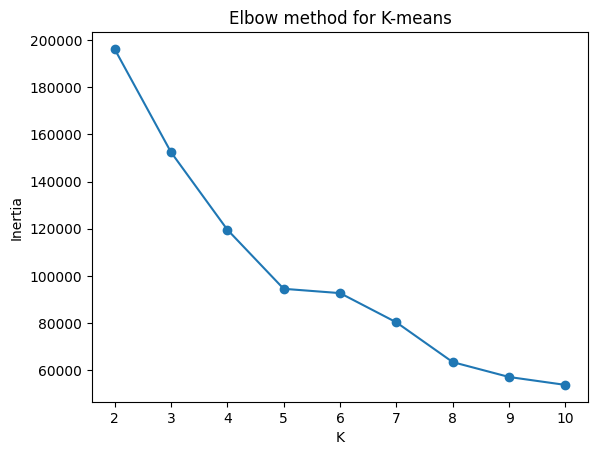

In [ ]:
# TODO: elbow method
from sklearn.cluster import KMeans

inertias = []
Ks = range(2, 11)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(Ks), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow method for K-means")
plt.show()

### 5.2 Fit K-means
Fit K-means using your chosen `K` and create cluster labels.

### Tasks
1. Fit K-means
2. Create `cluster_labels`
3. Add a `cluster` column to `df` (creating `df_clustered`)



In [ ]:
# TODO: fit K-means with your chosen K
# K = ...
# km = KMeans(n_clusters=K, random_state=42, n_init="auto")
# cluster_labels = km.fit_predict(X_scaled)
#
# df_clustered = df.copy()
# df_clustered["cluster"] = cluster_labels
# df_clustered.head()


In [ ]:
# Auto-check (do not edit)
assert "df_clustered" in globals(), "You must create df_clustered."
assert "cluster" in df_clustered.columns, "df_clustered must include a 'cluster' column."
n_clusters_found = df_clustered["cluster"].nunique()
assert n_clusters_found >= 2, "You should have at least 2 clusters."
print(f"Auto-check passed: clustering done (clusters found: {n_clusters_found}).")


AssertionError: You must create df_clustered.

## 6. Interpret clusters (descriptive, not causal)

### Tasks
- Compute descriptive summaries per cluster:
  - means (for numerical features)
  - cluster sizes
- Identify variables that seem to separate clusters

**Guiding questions**
- Are clusters clearly distinct?
- Which variables drive separation?
- Are you tempted to “name” clusters? What are the risks?


In [ ]:
# TODO: cluster sizes
# df_clustered["cluster"].value_counts().sort_index()


In [ ]:
# TODO: numerical summaries per cluster
# If you used X from numeric columns, you can do:
# df_clustered.groupby("cluster")[X.columns].mean()


## 7. PCA (Principal Component Analysis)

PCA reduces dimensionality by creating new axes (components) that preserve variance.
PCA does **not** know about clusters or meaning.

### Tasks
1. Fit PCA on `X_scaled`
2. Compute `X_pca`
3. Inspect explained variance ratio
4. Plot cumulative explained variance


In [ ]:
# TODO: apply PCA
# from sklearn.decomposition import PCA
# pca = PCA(random_state=42)
# X_pca = pca.fit_transform(X_scaled)


In [ ]:
# TODO: explained variance plots
# evr = pca.explained_variance_ratio_
# cum_evr = np.cumsum(evr)
# plt.figure()
# plt.plot(range(1, len(cum_evr)+1), cum_evr, marker="o")
# plt.xlabel("Number of components")
# plt.ylabel("Cumulative explained variance")
# plt.title("PCA: cumulative explained variance")
# plt.ylim(0, 1.05)
# plt.show()


In [ ]:
# Auto-check (do not edit)
assert "X_pca" in globals(), "You must create X_pca."
import numpy as np
assert isinstance(X_pca, np.ndarray), "X_pca should be a NumPy array."
assert X_pca.shape[0] == X_scaled.shape[0], "X_pca must keep the same number of rows."
assert X_pca.shape[1] >= 2, "X_pca should have at least 2 components."
print("Auto-check passed: PCA applied.")


### 7.1 Visualise clusters in PCA space

### Task
Create a scatter plot of:
- PC1 vs PC2
- colour by cluster label

**Reflection**
- Do clusters look more/less separable in PCA space?
- Does “visual separability” mean the clusters are meaningful?


In [ ]:
# TODO: PCA scatter plot coloured by cluster
# plt.figure()
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clustered["cluster"], s=10)
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("Clusters visualised in PCA space")
# plt.show()


## 8. Critical reflection (answer in Markdown)

- Did clustering reveal meaningful structure?
- How dependent are results on:
  - feature choice?
  - scaling?
  - number of clusters (K)?
- Would different groups obtain different clusters? Why?
- What are ethical risks of clustering people?


### Reflection

(Write your answers here.)


## 9. Save outputs

### Final tasks
Save:
1. the dataset with cluster labels as `adult_with_clusters.csv`
2. (optional) the PCA coordinates as `adult_pca_coords.csv`

Print the saved filenames and shapes.


In [ ]:
# TODO: save clustered dataset
# df_clustered.to_csv("adult_with_clusters.csv", index=False)
# print("Saved adult_with_clusters.csv", df_clustered.shape)

# TODO (optional): save PCA coordinates
# pca_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
# pca_df["cluster"] = df_clustered["cluster"].values
# pca_df.to_csv("adult_pca_coords.csv", index=False)
# print("Saved adult_pca_coords.csv", pca_df.shape)


In [ ]:
# Auto-check (do not edit)
import os
assert os.path.exists("adult_with_clusters.csv"), "You must save adult_with_clusters.csv"
print("Auto-check passed: outputs saved.")
